In [11]:
import io
import requests
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

TAP_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

query = '''
SELECT 
pl_orbper, 
pl_rade, 
st_met, 
discoverymethod
FROM pscomppars
'''

r = requests.get(
    TAP_URL,
    params={"query": query, "format": "csv"},
    timeout=120
)

exo = pd.read_csv(io.StringIO(r.text))

exo.head()

,pl_orbper,pl_rade,st_met,discoverymethod
0,1.003934,1.710000,-0.05,Transit
1,8.172400,3.323214,-0.06,Transit
2,6.283855,0.800000,0.07,Transit
3,3.173917,3.150000,0.08,Transit
4,56.358501,4.540605,-0.20,Transit


In [4]:
# definicija vrućih Jupitera
exo["VJ"] = ((exo["pl_orbper"] < 10) & (exo["pl_rade"] > 8)).astype(int)

# broj vrućih Jupitera
broj_VJ = exo["VJ"].sum()

# ukupan broj planeta u skupu
ukupno = len(exo)

# udeo u procentima
udio = 100 * broj_VJ / ukupno

print(f"Broj vrućih Jupitera: {broj_VJ}")
print(f"Ukupan broj planeta: {ukupno}")
print(f"Udeo vrućih Jupitera: {udio:.2f}%")

Broj vrućih Jupitera: 741
Ukupan broj planeta: 6298
Udeo vrućih Jupitera: 11.77%


In [5]:
# ceo uzorak
udio_svi = exo["VJ"].mean() * 100

# samo zvezde sa [Fe/H] > 0.4
metalne = exo[exo["st_met"] > 0.4]

udio_metalne = metalne["VJ"].mean() * 100

print(f"Udeo VJ u celom uzorku: {udio_svi:.2f}%")
print(f"Udeo VJ za [Fe/H] > 0.4: {udio_metalne:.2f}%")

Udeo VJ u celom uzorku: 11.77%
Udeo VJ za [Fe/H] > 0.4: 36.36%


In [38]:
# izdvajanje uzorka

x = metalne["st_met"].dropna().values
N = len(x)

x_mean = np.mean(x)
s = np.std(x, ddof=1)

print("N =", N)
print("srednja vrednost =", x_mean)
print("standardna devijacija =", s)

N = 77
srednja vrednost = 0.4544753246753246
standardna devijacija = 0.06353087967744953


In [39]:
# Broj bootstrap resamplovanih uzoraka
B = 10000

# Liste u koje ćemo čuvati bootstrap procene srednje vrednosti i standardne devijacije
bootstrap_means = []
bootstrap_std = []

# Petlja kroz sve bootstrap realizacije
for i in range(B):
    
    # Generisanje novog uzorka veličine N sa vraćanjem (sampling with replacement)
    sample = np.random.choice(x, size=N, replace=True)
    
    # Računanje srednje vrednosti bootstrap uzorka
    bootstrap_means.append(np.mean(sample))
    
    # Računanje standardne devijacije bootstrap uzorka
    # ddof=1 daje uzoračku standardnu devijaciju
    bootstrap_std.append(np.std(sample, ddof=1))

# Pretvaranje lista u NumPy nizove radi lakše analize i crtanja
bootstrap_means = np.array(bootstrap_means)
bootstrap_std = np.array(bootstrap_std)

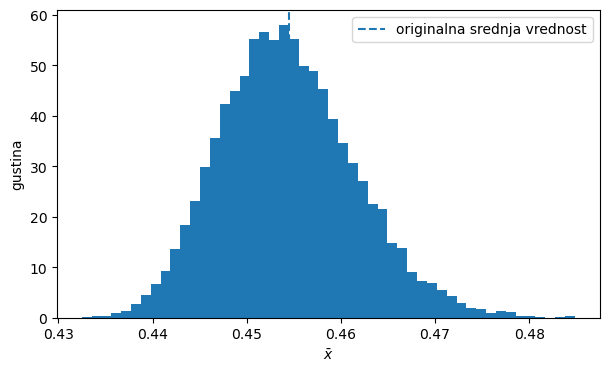

Bootstrap sigma_x = 0.007147197455078597
Analiticka sigma_x = 0.007240015671030045


In [40]:
# Prikaz bootstrap raspodele srednjih vrednosti

plt.figure(figsize=(7,4))   # kreiranje figure dimenzija 7x4

plt.hist(
    bootstrap_means,
    bins=50,                 # broj binova histograma
    density=True             # normalizacija tako da površina ispod histograma bude 1
)

plt.axvline(
    x_mean,                  # originalna srednja vrednost uzorka
    linestyle="--",          # isprekidana vertikalna linija
    label="originalna srednja vrednost"
)

plt.xlabel(r"$\bar{x}$")     # oznaka x ose: srednja vrednost
plt.ylabel("gustina")        # oznaka y ose: gustina verovatnoće
plt.legend()                 # prikaz legende

plt.show()                   # prikaz grafa


# Bootstrap procena standardne greške srednje vrednosti
sigma_mean_boot = np.std(
    bootstrap_means,
    ddof=1                   # uzoračka standardna devijacija
)

# Analitička procena standardne greške srednje vrednosti:
# sigma_x = s / sqrt(N)
sigma_mean_an = s / np.sqrt(N)


# Ispis poređenja bootstrap i analitičkog rezultata
print("Bootstrap sigma_x =", sigma_mean_boot)
print("Analiticka sigma_x =", sigma_mean_an)

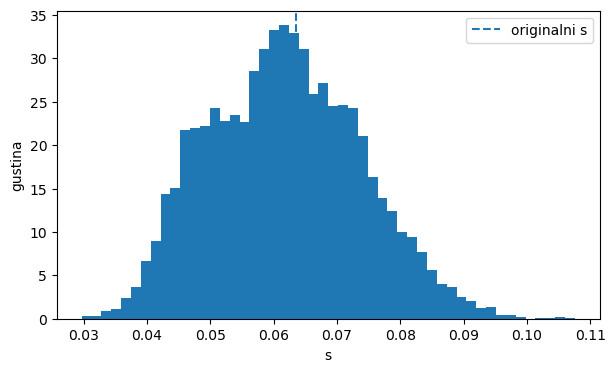

Bootstrap sigma_s = 0.011987477672503558
Analiticka sigma_s = 0.005153034793481672


In [41]:
# Prikaz bootstrap raspodele standardnih devijacija

plt.figure(figsize=(7,4))   # kreiranje figure dimenzija 7x4

plt.hist(
    bootstrap_std,
    bins=50,                 # broj intervala histograma
    density=True             # normalizacija histograma u gustinu verovatnoće
)

plt.axvline(
    s,                       # originalna standardna devijacija uzorka
    linestyle="--",          # isprekidana linija
    label="originalni s"
)

plt.xlabel("s")              # oznaka x ose: standardna devijacija
plt.ylabel("gustina")        # oznaka y ose: gustina verovatnoće
plt.legend()                 # prikaz legende

plt.show()                   # prikaz grafa


# Bootstrap procena standardne greške standardne devijacije
sigma_s_boot = np.std(
    bootstrap_std,
    ddof=1                   # uzoračka standardna devijacija bootstrap raspodele
)


# Analitička procena:
# sigma_s = s / sqrt(2(N-1))
sigma_s_an = s / np.sqrt(2*(N-1))


# Poređenje bootstrap i analitičke procene
print("Bootstrap sigma_s =", sigma_s_boot)
print("Analiticka sigma_s =", sigma_s_an)

Bootstrap raspodela srednje vrednosti bi trebalo da bude približno simetrična i normalna. To je posledica centralne granične teoreme: srednja vrednost velikog broja nezavisnih merenja teži normalnoj raspodeli čak i kada originalna raspodela nije savršeno normalna.

Bootstrap raspodela standardne devijacije obično nije potpuno normalna.
Razlog je što je s pozitivna veličina i njena raspodela može biti:
-asimetrična,
-pomerena ka većim vrednostima,
-zavisna od veličine uzorka.

Jackknife bi verovatno dao dobru procenu greške za srednju vrednost, ali za standardnu devijaciju može biti lošiji. On koristi samo N uzoraka (izbacivanje jednog elementa), a bootstrap koristi veliki broj resamplovanih uzoraka i bolje opisuje oblik raspodele.

3 GaussianMixture(n_components=3)


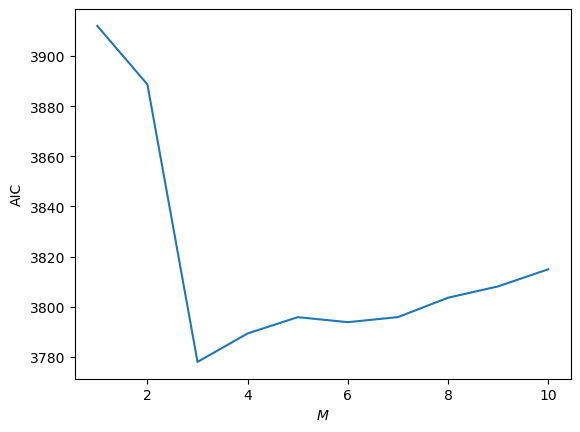

In [20]:
import numpy as np
from sklearn.mixture import GaussianMixture as GM

# instalacija:
# pip install -U scikit-learn
# conda install -c conda-forge scikit-learn

rs = np.random.RandomState(seed=1)

X = np.concatenate([
    rs.normal(-1, 1.5, 350),
    rs.normal(0, 1, 500),
    rs.normal(3, 0.5, 150)
]).reshape(-1, 1)

N = np.arange(1, 11)

modeli = [None for i in range(len(N))]

for i in range(len(N)):
    modeli[i] = GM(n_components=N[i]).fit(X)

AIC = [m.aic(X) for m in modeli]

najbolje_N = N[np.argmin(AIC)]
najbolji_model = modeli[np.argmin(AIC)]

print(najbolje_N, najbolji_model)

plt.plot(N, AIC)
plt.xlabel('$M$')
plt.ylabel('AIC')
plt.show()

In [21]:
Rp = exo["pl_rade"].dropna().values
Rp = Rp.reshape(-1,1)

In [24]:
# Testiranje razlicitih brojeva komponenti:
from sklearn.mixture import GaussianMixture as GM
import numpy as np
import matplotlib.pyplot as plt

N = np.arange(1,11)

modeli_Rp = [None for i in range(len(N))]

for i in range(len(N)):
    modeli_Rp[i] = GM(
        n_components=N[i],
        random_state=1
    ).fit(Rp)

AIC_Rp = [m.aic(Rp) for m in modeli_Rp]

najbolje_M = N[np.argmin(AIC_Rp)]

print("Optimalan broj komponenti:", najbolje_M)

Optimalan broj komponenti: 10


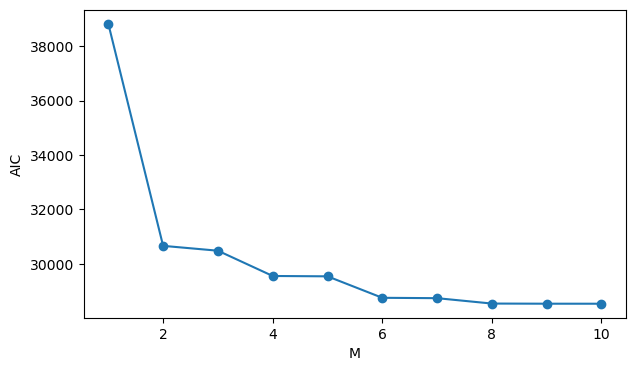

In [23]:
# AIC
plt.figure(figsize=(7,4))

plt.plot(N, AIC_Rp, marker="o")

plt.xlabel("M")
plt.ylabel("AIC")

plt.show()

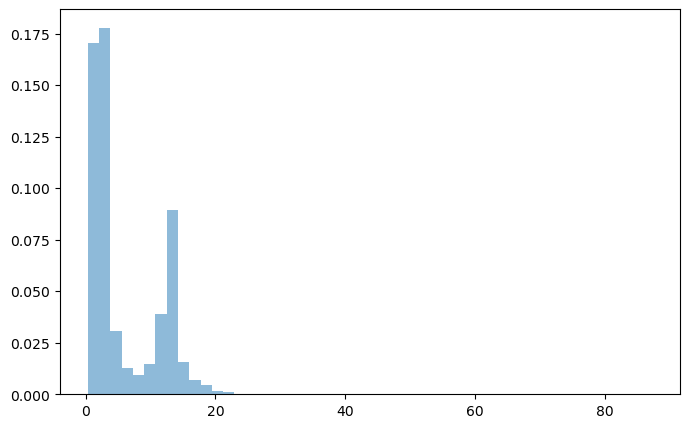

In [26]:
# Prikaz fitovanih raspodela:
plt.figure(figsize=(8,5))

plt.hist(
    Rp,
    bins=50,
    density=True,
    alpha=0.5,
    label="podaci"
)

x = np.linspace(
    Rp.min(),
    Rp.max(),
    1000
).reshape(-1,1)

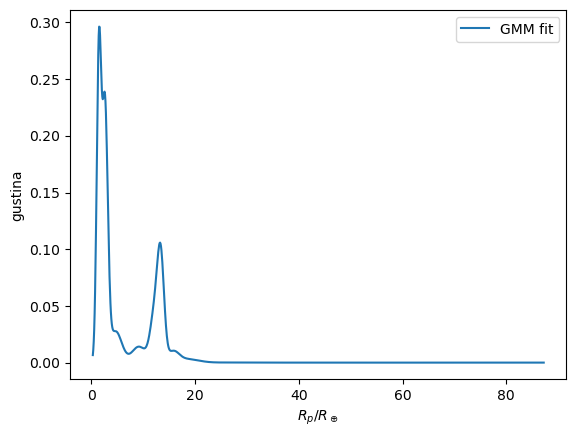

In [27]:
model = modeli_Rp[np.argmin(AIC_Rp)]
logprob = model.score_samples(x)
pdf = np.exp(logprob)

plt.plot(
    x,
    pdf,
    label="GMM fit"
)

plt.xlabel(r"$R_p/R_\oplus$")
plt.ylabel("gustina")
plt.legend()

plt.show()


In [35]:
# Tranzitne planete:
transit = exo[
    exo["discoverymethod"] == "Transit"
]

Rp_transit = transit["pl_rade"].dropna().values
Rp_transit = Rp_transit.reshape(-1,1)

modeli_transit = [None for i in range(len(N))]

for i in range(len(N)):
    modeli_transit[i] = GM(
        n_components=N[i],
        random_state=1
    ).fit(Rp_transit)

AIC_transit = [
    m.aic(Rp_transit)
    for m in modeli_transit
]

M_transit = N[np.argmin(AIC_transit)]

print("Transit optimalni M:", M_transit)


Transit optimalni M: 9


In [36]:
query = '''
SELECT
pl_name,
pl_eqt,
sy_snum,
sy_pnum,
disc_telescope,
pl_bmasse,
pl_orbeccen
FROM pscomppars
WHERE pl_eqt IS NOT NULL
'''

r = requests.get(
    TAP_URL,
    params={"query": query, "format": "csv"},
    timeout=120
)

teq_data = pd.read_csv(io.StringIO(r.text))

teq_data.head()

Teq_earth = 255   # K
teq_data["diff"] = abs(teq_data["pl_eqt"] - Teq_earth)
najbliza = teq_data.sort_values("diff").iloc[0]

print("Planeta:", najbliza["pl_name"])
print("Teq:", najbliza["pl_eqt"], "K")
print("Broj zvezda u sistemu:", najbliza["sy_snum"])
print("Broj planeta u sistemu:", najbliza["sy_pnum"])
print("Teleskop:", najbliza["disc_telescope"])
print("Masa:", najbliza["pl_bmasse"], "M⊕")
print("Ekscentricitet:", najbliza["pl_orbeccen"])

Planeta: HD 40307 g
Teq: 255.0 K
Broj zvezda u sistemu: 1
Broj planeta u sistemu: 5
Teleskop: 3.6 m ESO Telescope
Masa: 7.1 M⊕
Ekscentricitet: 0.29
